In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time

def get_steam_top_sellers():
   driver = webdriver.Chrome()
   driver.get('https://store.steampowered.com/charts/topsellers/TW/2024-12-17')
   
   # 等待40秒讓頁面完全載入
   time.sleep(40)
   
   # 點擊"查看所有100項"按鈕
   view_all_button = driver.find_element(By.CLASS_NAME, 'DialogButton._DialogLayout.Primary.Focusable')
   view_all_button.click()
   
   # 再等待載入
   time.sleep(3)
   
   games = []
   # 找到所有遊戲標題和價格
   titles = driver.find_elements(By.CLASS_NAME, '_1n_4-zvf0n4aqGEksbgW9N')
   prices = driver.find_elements(By.CLASS_NAME, '_3j4dI1yA7cRfCvK8h406OB')
   
   # 將標題和價格配對
   for title, price in zip(titles, prices):
       games.append({
           'title': title.text,
           'price': price.text
       })
   
   driver.quit()
   
   return pd.DataFrame(games)

# 執行爬蟲
df = get_steam_top_sellers()

# 儲存成CSV
df.to_csv('steam_top_sellers.csv', index=False, encoding='utf-8-sig')
print(df)

NoSuchWindowException: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=131.0.6778.205)
Stacktrace:
	GetHandleVerifier [0x00007FF74959FB05+28789]
	(No symbol) [0x00007FF7495086E0]
	(No symbol) [0x00007FF7493A592A]
	(No symbol) [0x00007FF74937F505]
	(No symbol) [0x00007FF749426477]
	(No symbol) [0x00007FF74943EF42]
	(No symbol) [0x00007FF74941F1E3]
	(No symbol) [0x00007FF7493EA938]
	(No symbol) [0x00007FF7493EBAA1]
	GetHandleVerifier [0x00007FF7498D933D+3410093]
	GetHandleVerifier [0x00007FF7498EE7DD+3497293]
	GetHandleVerifier [0x00007FF7498E2A73+3448803]
	GetHandleVerifier [0x00007FF749667BBB+848171]
	(No symbol) [0x00007FF749513C3F]
	(No symbol) [0x00007FF74950F6E4]
	(No symbol) [0x00007FF74950F87D]
	(No symbol) [0x00007FF7494FED49]
	BaseThreadInitThunk [0x00007FF9FC99259D+29]
	RtlUserThreadStart [0x00007FF9FD76AF38+40]


In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd
import time

def get_steam_top_sellers(date, driver, is_first=False):
    driver.get(f'https://store.steampowered.com/charts/topsellers/TW/{date}')
    
    if is_first:
        time.sleep(50)
    else:
        time.sleep(3)
    
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)
    
    try:
        view_all_button = driver.find_element(By.CSS_SELECTOR, "button.DialogButton[type='button']")
        view_all_button.click()
        time.sleep(3)
    except:
        print(f"無法找到'查看所有'按鈕 - {date}")
    
    games = []
    try:
        titles = driver.find_elements(By.CLASS_NAME, '_1n_4-zvf0n4aqGEksbgW9N')
        prices = driver.find_elements(By.CLASS_NAME, '_3j4dI1yA7cRfCvK8h406OB')
        
        for title, price in zip(titles, prices):
            games.append({
                'date': date,
                'title': title.text,
                'price': price.text
            })
        
        print(f"\n=== {date} 爬取結果 ===")
        for i, game in enumerate(games, 1):
            print(f"{i}. {game['title']} - {game['price']}")
        print(f"總共爬取到 {len(games)} 筆資料\n")
            
    except Exception as e:
        print(f"爬取錯誤 - {date}: {str(e)}")
    
    return games

def crawl_yearly_data():
    all_games = []
    dates_by_year = {
        '2021': [
            "2021-1-5", "2021-1-12", "2021-1-19", "2021-1-26",
            "2021-2-2", "2021-2-9", "2021-2-16", "2021-2-23",
            "2021-3-2", "2021-3-9", "2021-3-16", "2021-3-23", "2021-3-30",
            "2021-4-6", "2021-4-13", "2021-4-20", "2021-4-27",
            "2021-5-4", "2021-5-11", "2021-5-18", "2021-5-25",
            "2021-6-1", "2021-6-8", "2021-6-15", "2021-6-22", "2021-6-29",
            "2021-7-6", "2021-7-13", "2021-7-20", "2021-7-27",
            "2021-8-3", "2021-8-10", "2021-8-17", "2021-8-24", "2021-8-31",
            "2021-9-7", "2021-9-14", "2021-9-21", "2021-9-28",
            "2021-10-5", "2021-10-12", "2021-10-19", "2021-10-26",
            "2021-11-2", "2021-11-9", "2021-11-16", "2021-11-23", "2021-11-30",
            "2021-12-7", "2021-12-14", "2021-12-21", "2021-12-28"
        ],
        '2022': [
            "2022-1-4", "2022-1-11", "2022-1-18", "2022-1-25",
            "2022-2-1", "2022-2-8", "2022-2-15", "2022-2-22",
            "2022-3-1", "2022-3-8", "2022-3-15", "2022-3-22", "2022-3-29",
            "2022-4-5", "2022-4-12", "2022-4-19", "2022-4-26",
            "2022-5-3", "2022-5-10", "2022-5-17", "2022-5-24", "2022-5-31",
            "2022-6-7", "2022-6-14", "2022-6-21", "2022-6-28",
            "2022-7-5", "2022-7-12", "2022-7-19", "2022-7-26",
            "2022-8-2", "2022-8-9", "2022-8-16", "2022-8-23", "2022-8-30",
            "2022-9-6", "2022-9-13", "2022-9-20", "2022-9-27",
            "2022-10-4", "2022-10-11", "2022-10-18", "2022-10-25",
            "2022-11-1", "2022-11-8", "2022-11-15", "2022-11-22", "2022-11-29",
            "2022-12-6", "2022-12-13", "2022-12-20", "2022-12-27"
        ],
        '2023': [
            "2023-1-3", "2023-1-10", "2023-1-17", "2023-1-24", "2023-1-31",
            "2023-2-7", "2023-2-14", "2023-2-21", "2023-2-28",
            "2023-3-7", "2023-3-14", "2023-3-21", "2023-3-28",
            "2023-4-4", "2023-4-11", "2023-4-18", "2023-4-25",
            "2023-5-2", "2023-5-9", "2023-5-16", "2023-5-23", "2023-5-30",
            "2023-6-6", "2023-6-13", "2023-6-20", "2023-6-27",
            "2023-7-4", "2023-7-11", "2023-7-18", "2023-7-25",
            "2023-8-1", "2023-8-8", "2023-8-15", "2023-8-22", "2023-8-29",
            "2023-9-5", "2023-9-12", "2023-9-19", "2023-9-26",
            "2023-10-3", "2023-10-10", "2023-10-17", "2023-10-24", "2023-10-31",
            "2023-11-7", "2023-11-14", "2023-11-21", "2023-11-28",
            "2023-12-5", "2023-12-12", "2023-12-19", "2023-12-16"
        ],
        '2024': [
            "2024-1-2", "2024-1-9", "2024-1-16", "2024-1-23", "2024-1-30",
            "2024-2-6", "2024-2-13", "2024-2-20", "2024-2-27",
            "2024-3-5", "2024-3-12", "2024-3-19", "2024-3-26",
            "2024-4-2", "2024-4-9", "2024-4-16", "2024-4-23", "2024-4-30",
            "2024-5-7", "2024-5-14", "2024-5-21", "2024-5-28",
            "2024-6-4", "2024-6-11", "2024-6-18", "2024-6-25",
            "2024-7-2", "2024-7-9", "2024-7-16", "2024-7-23", "2024-7-30",
            "2024-8-6", "2024-8-13", "2024-8-20", "2024-8-27",
            "2024-9-3", "2024-9-10", "2024-9-17", "2024-9-24",
            "2024-10-1", "2024-10-8", "2024-10-15", "2024-10-22", "2024-10-29",
            "2024-11-5", "2024-11-12", "2024-11-19", "2024-11-26",
            "2024-12-3", "2024-12-10", "2024-12-17"
        ]
    }
    
    driver = webdriver.Chrome()
    
    for year, dates in dates_by_year.items():
        print(f"\n開始爬取 {year} 年度資料...")
        for i, date in enumerate(dates):
            print(f"正在爬取 {date} 的資料...")
            games = get_steam_top_sellers(date, driver, is_first=(i==0 and year=='2024'))
            if games:
                all_games.extend(games)
            time.sleep(2)
    
    driver.quit()
    
    df = pd.DataFrame(all_games)
    df.to_csv('steam_yearly_data.csv', index=False, encoding='utf-8-sig')
    return df

if __name__ == "__main__":
    crawl_yearly_data()


開始爬取 2021 年度資料...
正在爬取 2021-1-5 的資料...

=== 2021-1-5 爬取結果 ===
1. Counter-Strike 2 - 免費遊玩
2. 《Apex 英雄》 - 免費遊玩
3. Soulworker (靈魂行者) - 免費遊玩
4. Conqueror's Blade - 免費遊玩
5. PUBG: BATTLEGROUNDS - 免費遊玩
6. Warframe - 免費遊玩
7. Monster Hunter: World - NT$ 304.00
8. 糖豆人 - NT$ 79.00
9. 夏日狂想曲：鄉間的難忘回憶 - NT$ 227.00
10. Tom Clancy's Rainbow Six® Siege - NT$ 719.00
11. Cyberpunk 2077 - NT$ 120.00
12. 夏日狂想曲+ - NT$ 482.00
13. Grand Theft Auto V - NT$ 132.00
14. Dead by Daylight - NT$ 590.00
15. Red Dead Redemption 2 - NT$ 307.00
16. Monster Hunter World: Iceborne - 免費遊玩
17. Yu-Gi-Oh! Duel Links - NT$ 380.00
18. Age of Empires II: Definitive Edition - NT$ 347.00
19. Rust - NT$ 206.00
20. 槍火重生 - NT$ 163.00
21. Hades - NT$ 47.00
22. State of Decay 2: Juggernaut Edition - 免費遊玩
23. The Sims™ 4 - NT$ 1,074.00
24. NBA 2K21 - NT$ 574.00
25. 三國志14 - NT$ 696.00
26. Total War: THREE KINGDOMS - 免費遊玩
27. 無法使用的遊戲
（您的地區無法使用） - NT$ 544.00
28. 萊莎的鍊金工房２ ～失落傳說與秘密妖精～ - NT$ 1,490.00
29. 天命2 - 免費遊玩
30. Sea of Thieves: 2024 Ed

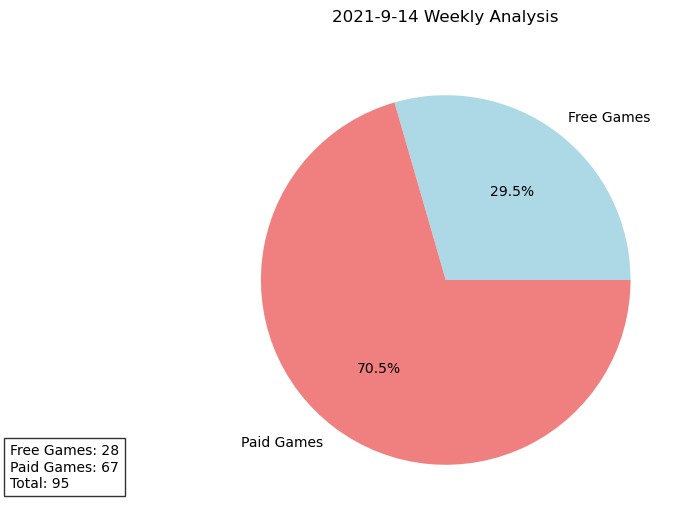

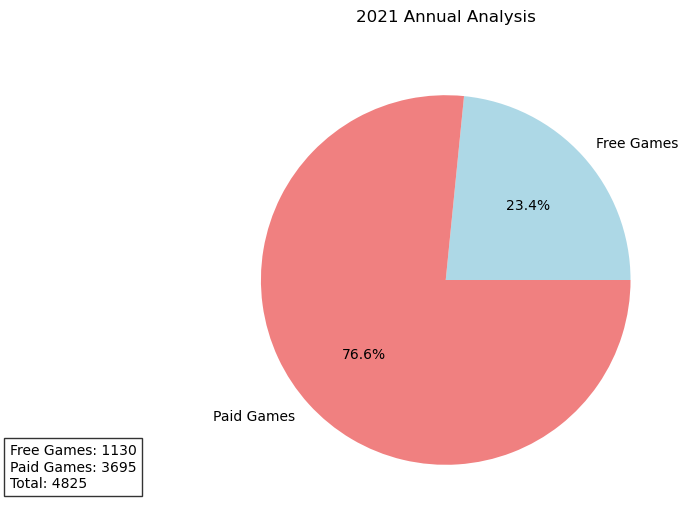

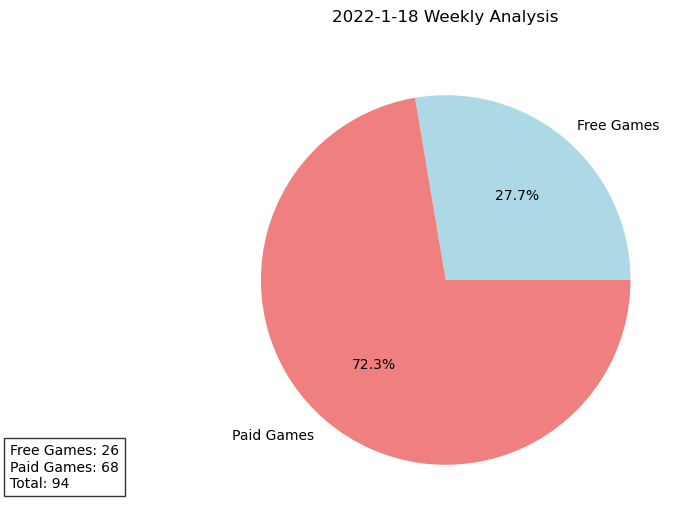

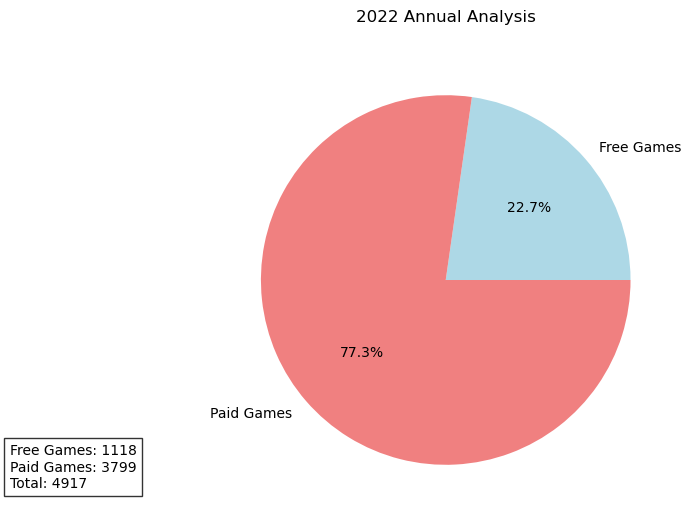

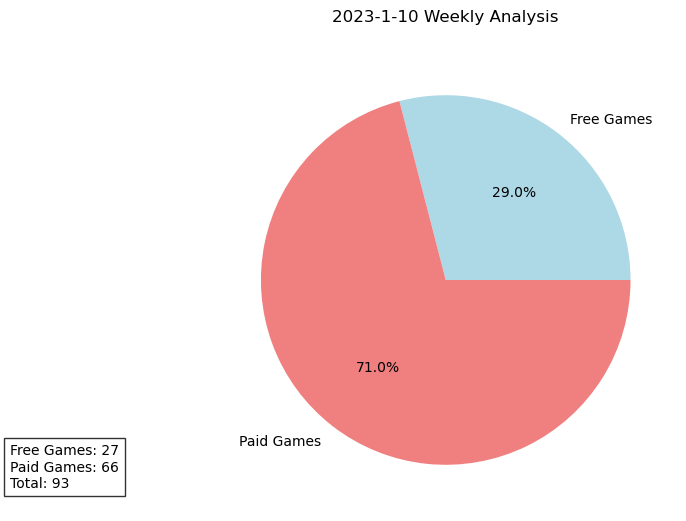

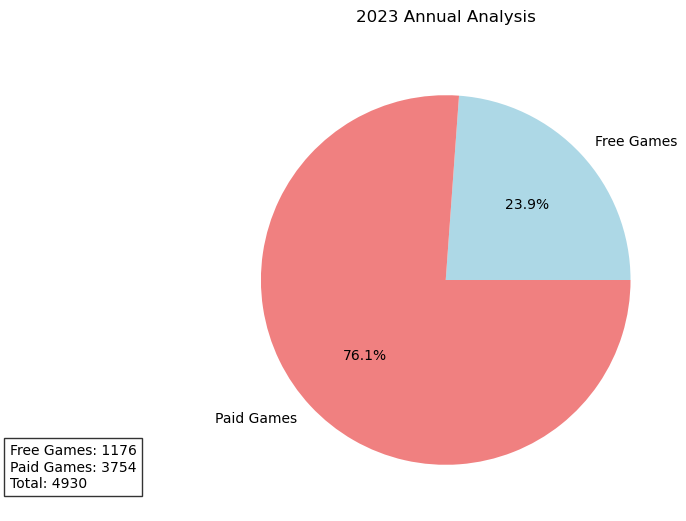

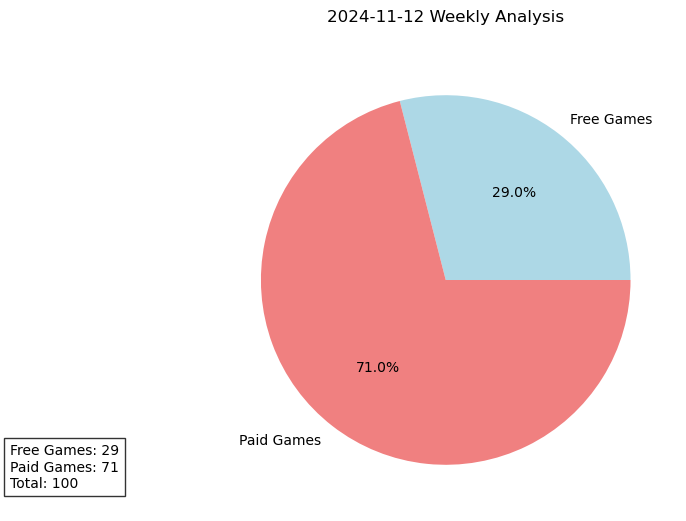

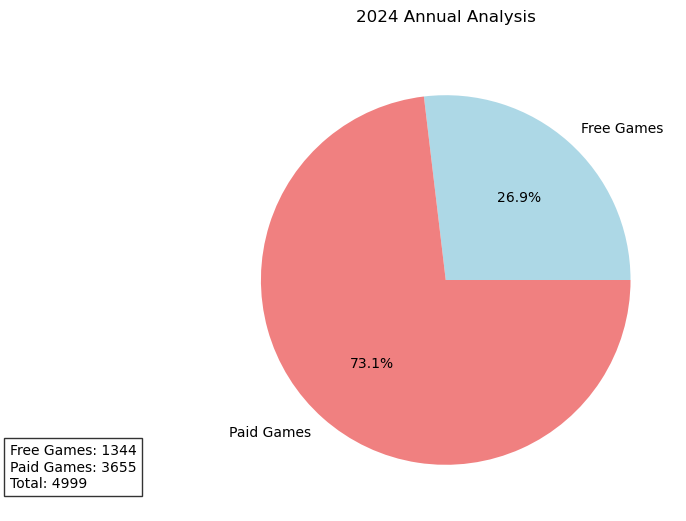

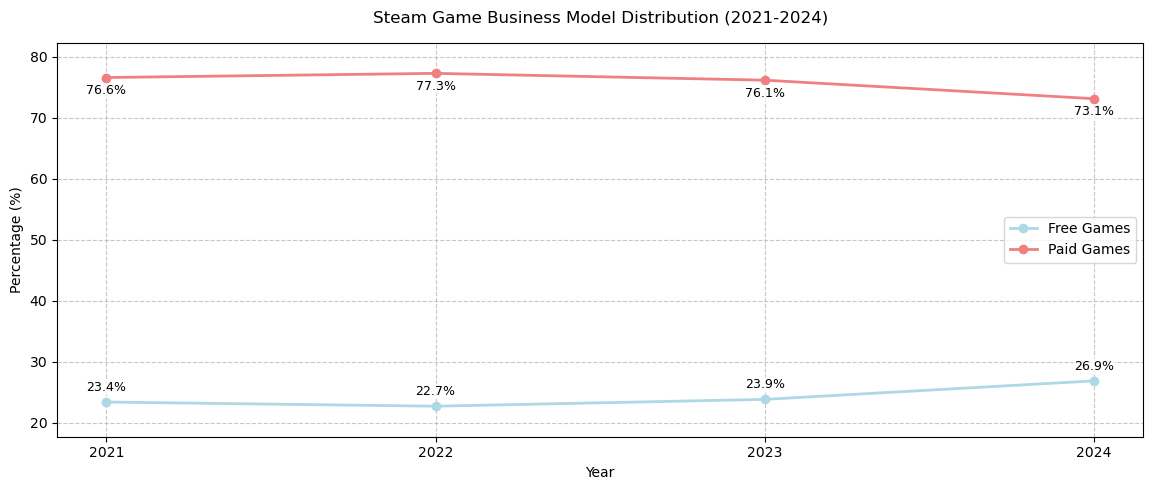

In [2]:
import tkinter as tk
from tkinter import ttk
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

class SteamAnalyzerGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Steam遊戲商業模式趨勢分析 (2021-2024)")
        self.root.geometry("1600x1000")
        
        # 讀取數據
        self.df = pd.read_csv('steam_yearly_data.csv')
        
        # 建立UI元素
        self.create_widgets()
        
    def create_widgets(self):
        # 主框架
        main_frame = ttk.Frame(self.root, padding="20")
        main_frame.grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))
        
        # 選擇區域
        select_frame = ttk.LabelFrame(main_frame, text="選擇分析時間", padding="10")
        select_frame.grid(row=0, column=0, columnspan=2, sticky=(tk.W, tk.E), pady=10)
        
        # 年份選擇
        self.year_var = tk.StringVar()
        year_label = ttk.Label(select_frame, text="選擇年份:", font=('Arial', 12))
        year_label.grid(row=0, column=0, padx=10)
        years = ['2021', '2022', '2023', '2024']
        year_combo = ttk.Combobox(select_frame, textvariable=self.year_var, 
                                 values=years, width=10, font=('Arial', 12))
        year_combo.grid(row=0, column=1, padx=10)
        year_combo.bind('<<ComboboxSelected>>', self.update_dates)
        
        # 日期選擇
        self.date_var = tk.StringVar()
        date_label = ttk.Label(select_frame, text="選擇日期:", font=('Arial', 12))
        date_label.grid(row=0, column=2, padx=10)
        self.date_combo = ttk.Combobox(select_frame, textvariable=self.date_var, 
                                      width=30, font=('Arial', 12))
        self.date_combo.grid(row=0, column=3, padx=10)
        
        # 按鈕區域
        button_frame = ttk.Frame(main_frame)
        button_frame.grid(row=1, column=0, columnspan=2, pady=20)
        
        style = ttk.Style()
        style.configure('Big.TButton', padding=(20, 10), font=('Arial', 12))
        
        analyze_btn = ttk.Button(button_frame, text="當週遊戲類型分析", 
                                command=self.analyze_week, style='Big.TButton')
        analyze_btn.grid(row=0, column=0, padx=10)
        
        yearly_btn = ttk.Button(button_frame, text="年度遊戲類型統計", 
                               command=self.analyze_year, style='Big.TButton')
        yearly_btn.grid(row=0, column=1, padx=10)
        
        weekly_rank_btn = ttk.Button(button_frame, text="當週遊戲排行榜", 
                                    command=self.show_weekly_ranking, style='Big.TButton')
        weekly_rank_btn.grid(row=0, column=2, padx=10)
        
        top_games_btn = ttk.Button(button_frame, text="年度熱門遊戲TOP100", 
                                  command=self.show_top_games, style='Big.TButton')
        top_games_btn.grid(row=0, column=3, padx=10)

        four_year_btn = ttk.Button(button_frame, text="四年度熱門遊戲TOP100", 
                                  command=self.show_four_year_top, style='Big.TButton')
        four_year_btn.grid(row=0, column=4, padx=10)

        type_trend_btn = ttk.Button(button_frame, text="四年度遊戲類型趨勢", 
                                   command=self.show_type_trend, style='Big.TButton')
        type_trend_btn.grid(row=0, column=5, padx=10)
        
        # 結果顯示區域
        self.result_frame = ttk.LabelFrame(main_frame, text="分析結果", padding="20")
        self.result_frame.grid(row=2, column=0, columnspan=2, sticky=(tk.W, tk.E, tk.N, tk.S))

        # 在這裡填入您的日期列表
        self.dates_by_year = {
        '2021': [
           "2021-1-5", "2021-1-12", "2021-1-19", "2021-1-26",
           "2021-2-2", "2021-2-9", "2021-2-16", "2021-2-23",
           "2021-3-2", "2021-3-9", "2021-3-16", "2021-3-23", "2021-3-30",
           "2021-4-6", "2021-4-13", "2021-4-20", "2021-4-27",
           "2021-5-4", "2021-5-11", "2021-5-18", "2021-5-25",
           "2021-6-1", "2021-6-8", "2021-6-15", "2021-6-22", "2021-6-29",
           "2021-7-6", "2021-7-13", "2021-7-20", "2021-7-27",
           "2021-8-3", "2021-8-10", "2021-8-17", "2021-8-24", "2021-8-31",
           "2021-9-7", "2021-9-14", "2021-9-21", "2021-9-28",
           "2021-10-5", "2021-10-12", "2021-10-19", "2021-10-26",
           "2021-11-2", "2021-11-9", "2021-11-16", "2021-11-23", "2021-11-30",
           "2021-12-7", "2021-12-14", "2021-12-21", "2021-12-28"
        ],
       '2022': [
           "2022-1-4", "2022-1-11", "2022-1-18", "2022-1-25",
           "2022-2-1", "2022-2-8", "2022-2-15", "2022-2-22",
           "2022-3-1", "2022-3-8", "2022-3-15", "2022-3-22", "2022-3-29",
           "2022-4-5", "2022-4-12", "2022-4-19", "2022-4-26",
           "2022-5-3", "2022-5-10", "2022-5-17", "2022-5-24", "2022-5-31",
           "2022-6-7", "2022-6-14", "2022-6-21", "2022-6-28",
           "2022-7-5", "2022-7-12", "2022-7-19", "2022-7-26",
           "2022-8-2", "2022-8-9", "2022-8-16", "2022-8-23", "2022-8-30",
           "2022-9-6", "2022-9-13", "2022-9-20", "2022-9-27",
           "2022-10-4", "2022-10-11", "2022-10-18", "2022-10-25",
           "2022-11-1", "2022-11-8", "2022-11-15", "2022-11-22", "2022-11-29",
           "2022-12-6", "2022-12-13", "2022-12-20", "2022-12-27"
       ],
       '2023': [
           "2023-1-3", "2023-1-10", "2023-1-17", "2023-1-24", "2023-1-31",
           "2023-2-7", "2023-2-14", "2023-2-21", "2023-2-28",
           "2023-3-7", "2023-3-14", "2023-3-21", "2023-3-28",
           "2023-4-4", "2023-4-11", "2023-4-18", "2023-4-25",
           "2023-5-2", "2023-5-9", "2023-5-16", "2023-5-23", "2023-5-30",
           "2023-6-6", "2023-6-13", "2023-6-20", "2023-6-27",
           "2023-7-4", "2023-7-11", "2023-7-18", "2023-7-25",
           "2023-8-1", "2023-8-8", "2023-8-15", "2023-8-22", "2023-8-29",
           "2023-9-5", "2023-9-12", "2023-9-19", "2023-9-26",
           "2023-10-3", "2023-10-10", "2023-10-17", "2023-10-24", "2023-10-31",
           "2023-11-7", "2023-11-14", "2023-11-21", "2023-11-28",
           "2023-12-5", "2023-12-12", "2023-12-19", "2023-12-16"
       ],
       '2024': [
           "2024-1-2", "2024-1-9", "2024-1-16", "2024-1-23", "2024-1-30",
           "2024-2-6", "2024-2-13", "2024-2-20", "2024-2-27",
           "2024-3-5", "2024-3-12", "2024-3-19", "2024-3-26",
           "2024-4-2", "2024-4-9", "2024-4-16", "2024-4-23", "2024-4-30",
           "2024-5-7", "2024-5-14", "2024-5-21", "2024-5-28",
           "2024-6-4", "2024-6-11", "2024-6-18", "2024-6-25",
           "2024-7-2", "2024-7-9", "2024-7-16", "2024-7-23", "2024-7-30",
           "2024-8-6", "2024-8-13", "2024-8-20", "2024-8-27",
           "2024-9-3", "2024-9-10", "2024-9-17", "2024-9-24",
           "2024-10-1", "2024-10-8", "2024-10-15", "2024-10-22", "2024-10-29",
           "2024-11-5", "2024-11-12", "2024-11-19", "2024-11-26",
           "2024-12-3", "2024-12-10", "2024-12-17"
       ]
    }

    def update_dates(self, event=None):
        selected_year = self.year_var.get()
        if selected_year:
            self.date_combo['values'] = self.dates_by_year[selected_year]
            self.date_var.set('')
    def analyze_week(self):
        selected_date = self.date_var.get()
        if not selected_date:
            return
            
        week_data = self.df[self.df['date'] == selected_date]
        
        free_games = week_data[week_data['price'] == '免費遊玩'].shape[0]
        paid_games = week_data[week_data['price'] != '免費遊玩'].shape[0]
        
        self.plot_pie_chart(free_games, paid_games, f"{selected_date} Weekly Analysis")
        
    def analyze_year(self):
        selected_year = self.year_var.get()
        if not selected_year:
            return
            
        year_data = self.df[self.df['date'].str.startswith(selected_year)]
        free_games = year_data[year_data['price'] == '免費遊玩'].shape[0]
        paid_games = year_data[year_data['price'] != '免費遊玩'].shape[0]
        
        self.plot_pie_chart(free_games, paid_games, f"{selected_year} Annual Analysis")

    def plot_pie_chart(self, free_games, paid_games, title):
        for widget in self.result_frame.winfo_children():
            widget.destroy()
            
        fig, ax = plt.subplots(figsize=(10, 6))
        sizes = [free_games, paid_games]
        labels = ['Free Games', 'Paid Games']
        colors = ['lightblue', 'lightcoral']
        
        wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, 
                                         autopct='%1.1f%%', textprops={'fontsize': 10})
        ax.set_title(title, pad=20, fontsize=12)
        
        info_text = f'Free Games: {free_games}\nPaid Games: {paid_games}\nTotal: {free_games + paid_games}'
        plt.figtext(0.15, 0.15, info_text, fontsize=10, 
                   bbox=dict(facecolor='white', alpha=0.8))
        
        canvas = FigureCanvasTkAgg(fig, master=self.result_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    def show_weekly_ranking(self):
        selected_date = self.date_var.get()
        if not selected_date:
            return
            
        week_data = self.df[self.df['date'] == selected_date]
        
        for widget in self.result_frame.winfo_children():
            widget.destroy()
            
        text_widget = tk.Text(self.result_frame, height=30, width=80, font=('Arial', 11))
        text_widget.pack(pady=10, padx=10)
        
        text_widget.insert(tk.END, f"{selected_date} 週排行榜\n")
        text_widget.insert(tk.END, "="*50 + "\n\n")
        
        for idx, (title, price) in enumerate(zip(week_data['title'], week_data['price']), 1):
            if idx <= 9:
                text_widget.insert(tk.END, f"第 0{idx} 名: {title} - {price}\n")
            else:
                text_widget.insert(tk.END, f"第 {idx} 名: {title} - {price}\n")
        
        text_widget.config(state='disabled')

    def show_top_games(self):
        selected_year = self.year_var.get()
        if not selected_year:
            return
            
        year_data = self.df[self.df['date'].str.startswith(selected_year)]
        game_stats = {}
        
        for idx, row in year_data.iterrows():
            title = row['title']
            if title not in game_stats:
                game_stats[title] = {'count': 0, 'rank_sum': 0}
            game_stats[title]['count'] += 1
            game_stats[title]['rank_sum'] += idx % 100
        
        for game in game_stats:
            game_stats[game]['avg_rank'] = game_stats[game]['rank_sum'] / game_stats[game]['count']
        
        sorted_games = sorted(
            game_stats.items(),
            key=lambda x: (-x[1]['count'], x[1]['avg_rank'])
        )[:100]
        
        for widget in self.result_frame.winfo_children():
            widget.destroy()
            
        text_widget = tk.Text(self.result_frame, height=30, width=80, font=('Arial', 11))
        text_widget.pack(pady=10, padx=10)
        
        text_widget.insert(tk.END, f"{selected_year}年度 熱門遊戲排行榜\n")
        text_widget.insert(tk.END, "="*50 + "\n\n")
        
        for idx, (title, stats) in enumerate(sorted_games, 1):
            if idx <= 9:
                text_widget.insert(tk.END, f"第 0{idx} 名: {title}\n")
            else:
                text_widget.insert(tk.END, f"第 {idx} 名: {title}\n")
            text_widget.insert(tk.END, f"     上榜次數: {stats['count']} 次\n")
            text_widget.insert(tk.END, f"     平均名次: {stats['avg_rank']:.1f}\n\n")
        
        text_widget.config(state='disabled')

    def show_four_year_top(self):
        game_stats = {}
        
        # 處理2021-2024所有數據
        for idx, row in self.df.iterrows():
            title = row['title']
            if title not in game_stats:
                game_stats[title] = {'count': 0, 'rank_sum': 0}
            game_stats[title]['count'] += 1
            game_stats[title]['rank_sum'] += idx % 100
        
        for game in game_stats:
            game_stats[game]['avg_rank'] = game_stats[game]['rank_sum'] / game_stats[game]['count']
        
        sorted_games = sorted(
            game_stats.items(),
            key=lambda x: (-x[1]['count'], x[1]['avg_rank'])
        )[:100]
        
        for widget in self.result_frame.winfo_children():
            widget.destroy()
            
        text_widget = tk.Text(self.result_frame, height=30, width=80, font=('Arial', 11))
        text_widget.pack(pady=10, padx=10)
        
        text_widget.insert(tk.END, "2021-2024年度 熱門遊戲排行榜\n")
        text_widget.insert(tk.END, "="*50 + "\n\n")
        
        for idx, (title, stats) in enumerate(sorted_games, 1):
            if idx <= 9:
                text_widget.insert(tk.END, f"第 0{idx} 名: {title}\n")
            else:
                text_widget.insert(tk.END, f"第 {idx} 名: {title}\n")
            text_widget.insert(tk.END, f"     上榜次數: {stats['count']} 次\n")
            text_widget.insert(tk.END, f"     平均名次: {stats['avg_rank']:.1f}\n\n")
        
        text_widget.config(state='disabled')

    def show_type_trend(self):
       years = ['2021', '2022', '2023', '2024']
       free_percentages = []
       paid_percentages = []
   
       for year in years:
           year_data = self.df[self.df['date'].str.startswith(year)]
           free_count = year_data[year_data['price'] == '免費遊玩'].shape[0]
           total_count = year_data.shape[0]
           free_percentage = (free_count / total_count) * 100
           paid_percentage = 100 - free_percentage
       
           free_percentages.append(free_percentage)
           paid_percentages.append(paid_percentage)
   
       # 清除舊圖
       for widget in self.result_frame.winfo_children():
           widget.destroy()
   
       # 創建新圖
       fig, ax = plt.subplots(figsize=(8, 5))
   
       # 繪製折線圖
       ax.plot(years, free_percentages, 'o-', color='lightblue', label='Free Games', linewidth=2)
       ax.plot(years, paid_percentages, 'o-', color='lightcoral', label='Paid Games', linewidth=2)
   
       # 設置圖表
       ax.set_xlabel('Year', fontsize=10)
       ax.set_ylabel('Percentage (%)', fontsize=10)
       ax.set_title('Steam Game Business Model Distribution (2021-2024)', fontsize=12, pad=15)
       ax.legend(fontsize=10, loc='center right')
       ax.grid(True, linestyle='--', alpha=0.7)
   
       # 在每個數據點添加標籤
       for i, (free, paid) in enumerate(zip(free_percentages, paid_percentages)):
           ax.annotate(f'{free:.1f}%', (years[i], free), 
                  textcoords="offset points", 
                  xytext=(0,8),
                  ha='center',
                  fontsize=9,
                  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
           ax.annotate(f'{paid:.1f}%', (years[i], paid), 
                  textcoords="offset points", 
                  xytext=(0,-12),
                  ha='center',
                  fontsize=9,
                  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
   
       # 設置Y軸範圍以留出空間給標籤
       ax.set_ylim(min(min(free_percentages), min(paid_percentages)) - 5,
               max(max(free_percentages), max(paid_percentages)) + 5)
   
       plt.tight_layout()
   
       canvas = FigureCanvasTkAgg(fig, master=self.result_frame)
       canvas.draw()
       canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

def main():
    root = tk.Tk()
    app = SteamAnalyzerGUI(root)
    root.mainloop()

if __name__ == "__main__":
    main()

In [ ]:
{
        '2021': [
           "2021-1-5", "2021-1-12", "2021-1-19", "2021-1-26",
           "2021-2-2", "2021-2-9", "2021-2-16", "2021-2-23",
           "2021-3-2", "2021-3-9", "2021-3-16", "2021-3-23", "2021-3-30",
           "2021-4-6", "2021-4-13", "2021-4-20", "2021-4-27",
           "2021-5-4", "2021-5-11", "2021-5-18", "2021-5-25",
           "2021-6-1", "2021-6-8", "2021-6-15", "2021-6-22", "2021-6-29",
           "2021-7-6", "2021-7-13", "2021-7-20", "2021-7-27",
           "2021-8-3", "2021-8-10", "2021-8-17", "2021-8-24", "2021-8-31",
           "2021-9-7", "2021-9-14", "2021-9-21", "2021-9-28",
           "2021-10-5", "2021-10-12", "2021-10-19", "2021-10-26",
           "2021-11-2", "2021-11-9", "2021-11-16", "2021-11-23", "2021-11-30",
           "2021-12-7", "2021-12-14", "2021-12-21", "2021-12-28"
        ],
       '2022': [
           "2022-1-4", "2022-1-11", "2022-1-18", "2022-1-25",
           "2022-2-1", "2022-2-8", "2022-2-15", "2022-2-22",
           "2022-3-1", "2022-3-8", "2022-3-15", "2022-3-22", "2022-3-29",
           "2022-4-5", "2022-4-12", "2022-4-19", "2022-4-26",
           "2022-5-3", "2022-5-10", "2022-5-17", "2022-5-24", "2022-5-31",
           "2022-6-7", "2022-6-14", "2022-6-21", "2022-6-28",
           "2022-7-5", "2022-7-12", "2022-7-19", "2022-7-26",
           "2022-8-2", "2022-8-9", "2022-8-16", "2022-8-23", "2022-8-30",
           "2022-9-6", "2022-9-13", "2022-9-20", "2022-9-27",
           "2022-10-4", "2022-10-11", "2022-10-18", "2022-10-25",
           "2022-11-1", "2022-11-8", "2022-11-15", "2022-11-22", "2022-11-29",
           "2022-12-6", "2022-12-13", "2022-12-20", "2022-12-27"
       ],
       '2023': [
           "2023-1-3", "2023-1-10", "2023-1-17", "2023-1-24", "2023-1-31",
           "2023-2-7", "2023-2-14", "2023-2-21", "2023-2-28",
           "2023-3-7", "2023-3-14", "2023-3-21", "2023-3-28",
           "2023-4-4", "2023-4-11", "2023-4-18", "2023-4-25",
           "2023-5-2", "2023-5-9", "2023-5-16", "2023-5-23", "2023-5-30",
           "2023-6-6", "2023-6-13", "2023-6-20", "2023-6-27",
           "2023-7-4", "2023-7-11", "2023-7-18", "2023-7-25",
           "2023-8-1", "2023-8-8", "2023-8-15", "2023-8-22", "2023-8-29",
           "2023-9-5", "2023-9-12", "2023-9-19", "2023-9-26",
           "2023-10-3", "2023-10-10", "2023-10-17", "2023-10-24", "2023-10-31",
           "2023-11-7", "2023-11-14", "2023-11-21", "2023-11-28",
           "2023-12-5", "2023-12-12", "2023-12-19", "2023-12-16"
       ],
       '2024': [
           "2024-1-2", "2024-1-9", "2024-1-16", "2024-1-23", "2024-1-30",
           "2024-2-6", "2024-2-13", "2024-2-20", "2024-2-27",
           "2024-3-5", "2024-3-12", "2024-3-19", "2024-3-26",
           "2024-4-2", "2024-4-9", "2024-4-16", "2024-4-23", "2024-4-30",
           "2024-5-7", "2024-5-14", "2024-5-21", "2024-5-28",
           "2024-6-4", "2024-6-11", "2024-6-18", "2024-6-25",
           "2024-7-2", "2024-7-9", "2024-7-16", "2024-7-23", "2024-7-30",
           "2024-8-6", "2024-8-13", "2024-8-20", "2024-8-27",
           "2024-9-3", "2024-9-10", "2024-9-17", "2024-9-24",
           "2024-10-1", "2024-10-8", "2024-10-15", "2024-10-22", "2024-10-29",
           "2024-11-5", "2024-11-12", "2024-11-19", "2024-11-26",
           "2024-12-3", "2024-12-10", "2024-12-17"
       ]
    }
